### Importing Necessary Libraris 

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from keras.datasets import cifar10

### Training Script for a small Image Classification model on Cifar10 Dataset

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 34ms/step - accuracy: 0.2351 - loss: 2.0275 - val_accuracy: 0.4414 - val_loss: 1.5369
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.4383 - loss: 1.5276 - val_accuracy: 0.5103 - val_loss: 1.3655
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.5006 - loss: 1.3748 - val_accuracy: 0.5634 - val_loss: 1.2301
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.5464 - loss: 1.2642 - val_accuracy: 0.5974 - val_loss: 1.1316
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.5830 - loss: 1.1761 - val_accuracy: 0.6212 - val_loss: 1.0751
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.6055 - loss: 1.1113 - val_accuracy: 0.6381 - val_loss: 1.0226
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6347 - loss: 1.0328 - val_accuracy: 0.6502 - val_loss: 0.9947
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6514 -

Loss: 0.851
Accuracy: 0.706


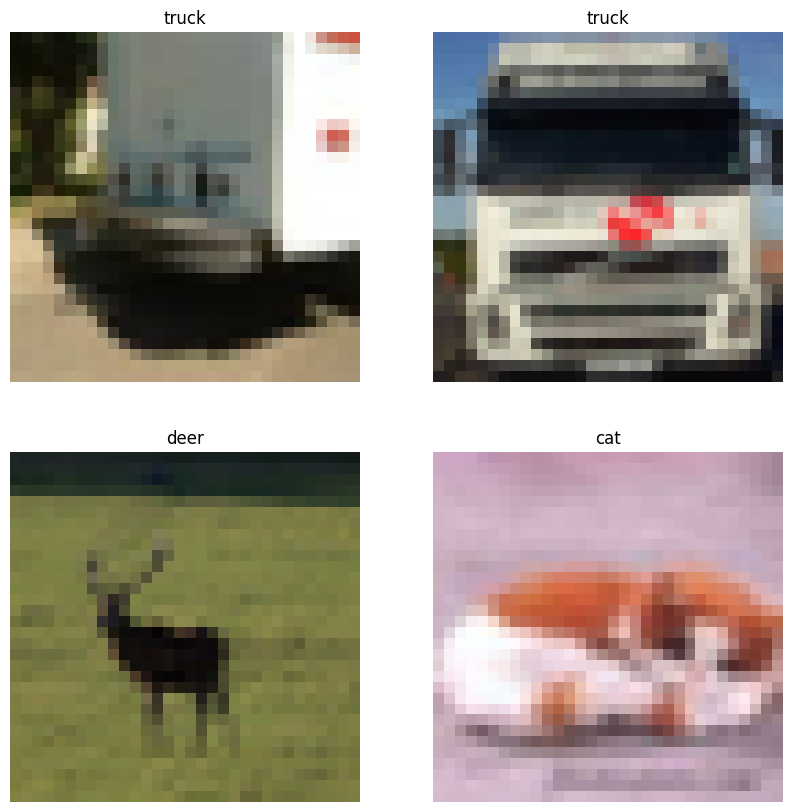

In [6]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# print('x_train shape:', x_train.shape)
# print(x_train.shape[0], 'train samples')

# print('y_train shape', y_train.shape)
# print(x_test.shape[0], 'test samples')

# print('x_test shape', x_test.shape)
# print(y_test.shape[0], 'test samples')

# Declare variables
batch_size = 32
# 32 examples in a mini-batch, smaller batch size means more updates in one epoch
epochs = 10 # Reduced epochs for quicker testing
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

def plot_images(x, y, number_of_images=2):
  fig, axes1 = plt.subplots(number_of_images,number_of_images,figsize=(10,10))
  for j in range(number_of_images):
      for k in range(number_of_images):
          i = np.random.choice(range(len(x)))
          title = class_names[y[i:i+1][0][0]]
          axes1[j][k].title.set_text(title)
          axes1[j][k].set_axis_off()
          axes1[j][k].imshow(x[i:i+1][0])

# Plot some images (optional)
plot_images(x_train, y_train)

model = tf.keras.Sequential()

# --- Start of Changes ---
# Use Input layer as the first layer
model.add(tf.keras.layers.Input(shape=(32, 32, 3)))
# Remove input_shape from the first Conv2D layer
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'))
# --- End of Changes ---

model.add(tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.25))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(1024, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(10, activation='softmax'))


# Compile the model
# --- Start of Changes ---
# Changed lr to learning_rate and removed the deprecated decay argument
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])
# --- End of Changes ---

# Train the model
model.fit(x_train / 255.0, tf.keras.utils.to_categorical(y_train),
          batch_size=batch_size,
          shuffle=True,
          epochs=epochs,
          validation_data=(x_test / 255.0, tf.keras.utils.to_categorical(y_test))
          )

# Evaluate the model
scores = model.evaluate(x_test / 255.0, tf.keras.utils.to_categorical(y_test))

print('Loss: %.3f' % scores[0])
print('Accuracy: %.3f' % scores[1])

# Save the model (optional)
model.save('cifar-model.h5')


In [7]:
from keras.models import load_model  
import coremltools

model = load_model('cifar-model.h5')
coreml_model = coremltools.converters.keras.convert(model,
	input_names="image",
	image_input_names="image",
	image_scale=1/255.0,
	class_labels=class_names)

coreml_model.save('CIFAR.mlmodel')

AttributeError: module 'coremltools.converters' has no attribute 'keras'

In [12]:
help(coremltools.convert)

Help on function convert in module coremltools.converters._converters_entry:

convert(model, source='auto', inputs=None, outputs=None, classifier_config=None, minimum_deployment_target=None, convert_to=None, compute_precision=None, skip_model_load=False, compute_units=<ComputeUnit.ALL: 1>, package_dir=None, debug=False, pass_pipeline: Optional[coremltools.converters.mil.mil.passes.pass_pipeline.PassPipeline] = None, states=None)
    Convert a TensorFlow or PyTorch model to the Core ML model format as either
    a neural network or an `ML program <https://apple.github.io/coremltools/docs-guides/source/convert-to-ml-program.html>`_.
    Some parameters and requirements differ for TensorFlow and PyTorch
    conversions.

    Parameters
    ----------

    model :
        TensorFlow 1, TensorFlow 2, or PyTorch model in one of the following
        formats:

        * TensorFlow versions 1.x

            - Frozen `tf.Graph <https://www.tensorflow.org/api_docs/python/tf/Graph>`_
            

In [14]:
from keras.models import load_model
import coremltools
import tensorflow as tf # Ensure tensorflow is imported if needed
import numpy as np # Ensure numpy is imported for ImageType shape

# Ensure class_names is defined in this scope if not defined earlier
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

model = load_model('cifar-model.h5')

# --- Corrected coremltools.convert call ---
coreml_model = coremltools.convert(
    model,
    source='tensorflow', # Explicitly specify the source framework
    # Specify input as ImageType with name, shape, and scale
    # Note: Shape might need batch dimension, e.g., (1, 32, 32, 3) or (None, 32, 32, 3)
    # Using (1, 32, 32, 3) for fixed batch size 1. Use ct.RangeDim() for flexible batch.
    inputs=[coremltools.ImageType(name="image", shape=(1, 32, 32, 3), scale=1/255.0)],
    # Specify classifier configuration with labels
    classifier_config=coremltools.ClassifierConfig(class_labels=class_names)
)
# --- End of correction ---

coreml_model.save('CIFAR.mlmodel')

print("Model converted and saved as CIFAR.mlmodel")

AttributeError: 'Sequential' object has no attribute '_get_save_spec'